# Assignment: Content-Based Music Recommendation

## Part 1: Topic Classification

### 1.1 Issues
**Special Characters**

The tutorial's approach to cleaning text might used a regex that removes too many special characters. For instance, a regex like `[^a-zA-Z\s]` would strip all non-alphabetic characters. This is problematic because it would remove apostrophes in contractions (e.g., "don't" becomes "dont") and hyphens in compound words. This can alter the meaning of words or create tokens that are not in standard dictionaries, **potentially reducing the effectiveness of preprocessing steps** like stopword removal or lemmatization.

The objective is to create cleaner, more meaningful tokens without discarding important information. We can achieve this by:
- **Preserve contractions**: modify the regex to keep apostrophes that are part of words (e.g., in contractions like "it's" or possessives like "artist's"). This ensures these common words are treated as single, meaningful tokens.
- **Handle hyphens**: Hyphenated words will be treated carefully. Instead of just removing the hyphen, they can be split into separate words or the hyphen can be replaced with a space.


**Evaluation**

The tutorial evaluates models using only one specific training-test split of the data. The performance metrics derived from a single split can be misleading; a model might perform well by chance on one particular test set but poorly on another. This method does not provide a reliable estimate of the model's ability to generalize to new, unseen data.


**Solution to special characters handling**

[`[^a-zA-Z0-9'’ –-]|(?<= )[–-] |(?<=[^a-zA-Z0-9])['’]|['’](?=[^a-zA-Z0-9])`](https://regex101.com/r/c9XGIr/1)
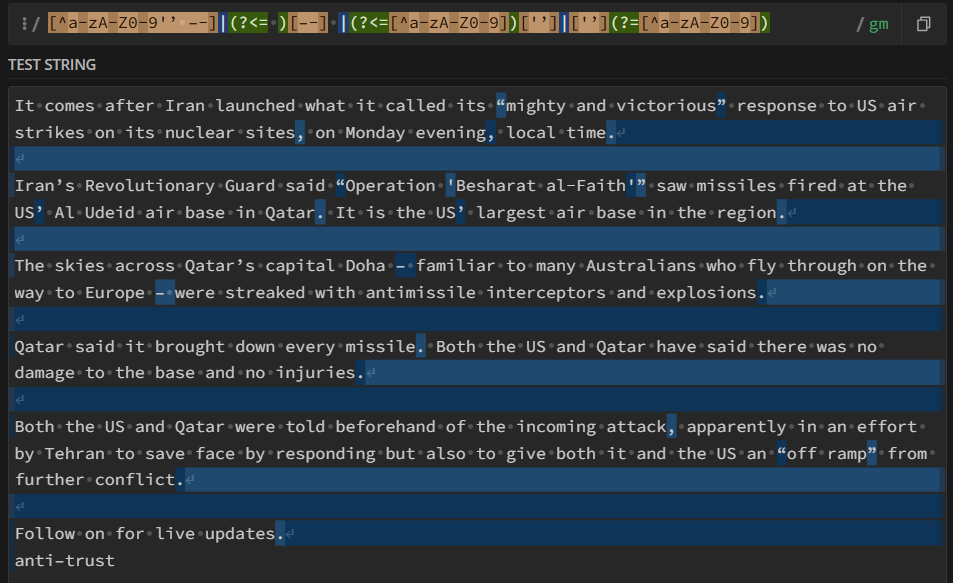
By splitting the expression into 4 different matching alternatives, I divided special characters to be removed into these 4 categories:
- Special characters excluding `'` `’` `–` `-` and space
- Patterns like `– ` or `- ` with a space in the front
- `'` or `’` with a non-alphabetical or non-numerical character in the front
- `'` or `’` followed by a non-alphabetical or non-numerical character

**Solution to incomplete evaluation**

Use k-fold cross-validation for all model evaluations. This involves spliting the dataset into `k` equal-sized subsets. Then a model will be trained using `k-1` of the folds as the training data, with a remaining fold as test fold. Repeat the process for `k` times

## 1.2 Multinomial Naive Bayes Model

The steps are as follows:

- **Load and Prepare Data**: Load the dataset and combine the `artist_name`, `track_name`, `genre`, and `lyrics` fields into a single text document for each song.
- **Define Preprocessing Functions**: Create functions for text cleaning, stemming, and lemmatization.
- **Run Experiments**: Systematically evaluate the performance of both BNB and MNB models with different combinations of preprocessing techniques using 5-fold cross-validation.
- **Summarize Findings**: Conclude by selecting the single best-performing preprocessing pipeline.

### 1.2.1 Setup and Data Preparation**
First, we import the necessary libraries and load the song data into a pandas DataFrame. We also download the required NLTK resources for stop words and lemmatization.

In [ ]:
import pandas as pd
import numpy as np
import nltk


# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Load the dataset
df = pd.read_csv('dataset.tsv', sep='\t')

# Combine the specified fields into a single 'document'
df['document'] = df['artist_name'] + ' ' + df['track_name'] + ' ' + df['genre'] + ' ' + df['lyrics']

# Define features (X) and target (y)
X = df['document']
y = df['topic']

print("Data loaded and combined 'document' feature created.")
print(f"Dataset shape: {df.shape}")
df['document'].head()
print(type(df['document']))

Data loaded and combined 'document' feature created.
Dataset shape: (1500, 7)
<class 'pandas.core.frame.DataFrame'>


### 1.2.2 Defining Preprocessing Steps
Several preprocessing configurations will be tested here. The core steps to consider are text cleaning, stopword removal, and stemming/lemmatization.

- **Text Cleaning**: As established previously, we use a function to lowercase the text and remove special characters while preserving apostrophes and hyphenated words.
- **Stop Words**: We will compare using no stopwords, the scikit-learn default list, and the NLTK list.
Stemming vs. Lemmatization: We will test the effect of applying Porter Stemmer and WordNet Lemmatizer versus using no normalization.

In [19]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize


# 1. Text Cleaning Function
def clean_text(text):
    # Lowercasing
    text = text.lower()  
    # Remove special characters with exceptions
    text = re.sub(r"[^a-zA-Z0-9'’ –-]|(?<= )[–-] |(?<=[^a-zA-Z0-9])['’]|['’](?=[^a-zA-Z0-9])", " ", text) 
    return text

# 2. Stemming Function
stemmer = PorterStemmer()
def stem_text(text):
    # print("hit stem")
    tokens = word_tokenize(text)
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

# 3. Lemmatization Function
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    # print("hit lem")
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(lemmatized_tokens)

# Stopword lists to test
sklearn_stopwords = list(stopwords.words('english'))
nltk_stopwords = list(nltk.corpus.stopwords.words('english'))

### 1.2.3 Experimentation: Finding the Best Pipeline
Running a series of experiments for comparison. For each experiment, we will build a pipeline that combines `CountVectorizer` with either a BNB or MNB classifier and evaluate it using 5-fold cross-validation. Mean accuracy is recorded.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Function to run an experiment and return results
def run_experiment(preprocessing_steps, X_data, y_data):
    results = {}
    
    # Define vectorizer with the specified preprocessing
    count_vec = CountVectorizer(
        preprocessor=preprocessing_steps.get('preprocessor'),
        stop_words=preprocessing_steps.get('stop_words')
    )
    # tfidf_vec = TfidfVectorizer(
    #     preprocessor=preprocessing_steps.get('preprocessor'),
    #     stop_words=preprocessing_steps.get('stop_words')
    # )
    
    # Test BernoulliNB
    bnb_pipeline = Pipeline([('vect', count_vec), ('clf', BernoulliNB())])
    bnb_scores = cross_val_score(bnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    results['BNB+count'] = bnb_scores.mean()
    # bnb_pipeline = Pipeline([('vect', tfidf_vec), ('clf', BernoulliNB())])
    # bnb_scores = cross_val_score(bnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    # results['BNB+tfidf'] = bnb_scores.mean()
    
    # Test MultinomialNB
    mnb_pipeline = Pipeline([('vect', count_vec), ('clf', MultinomialNB())])
    mnb_scores = cross_val_score(mnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    results['MNB+count'] = mnb_scores.mean()
    # mnb_pipeline = Pipeline([('vect', tfidf_vec), ('clf', MultinomialNB())])
    # mnb_scores = cross_val_score(mnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    # results['MNB+tfidf'] = mnb_scores.mean()
    
    return results

# Experiment configurations
experiments = {
    "Clean Only": {"preprocessor": clean_text, "stop_words": None},
    "Clean + Sklearn Stopwords": {"preprocessor": clean_text, "stop_words": 'english'},
    "Clean + NLTK Stopwords": {"preprocessor": clean_text, "stop_words": nltk_stopwords},
    "Clean + Sklearn Stopwords + Stem": {"preprocessor": lambda x: stem_text(clean_text(x)), "stop_words": 'english'},
    "Clean + Sklearn Stopwords + Lemmatize": {"preprocessor": lambda x: lemmatize_text(clean_text(x)), "stop_words": 'english'}
}

# Run all experiments
all_results = {}
for name, steps in experiments.items():
    print(f"Running experiment: {name}...")
    all_results[name] = run_experiment(steps, X, y)

# Format results into a DataFrame for comparison
results_df = pd.DataFrame(all_results).T
results_df['Average'] = results_df.mean(axis=1)
results_df.sort_values(by='Average', ascending=False, inplace=True)

print("\n--- Preprocessing Experiment Results (Mean Accuracy) ---")
print(results_df)

Running experiment: Clean Only...
Running experiment: Clean + Sklearn Stopwords...
Running experiment: Clean + NLTK Stopwords...
Running experiment: Clean + Sklearn Stopwords + Stem...


c:\Users\z5612172\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'thi', 'thu', 'togeth', 'twelv', 'twenti', 'veri', 'wa', 'whatev', 'whenc', 'whenev', 'wherea', 'whereaft', 'wherebi', 'wherev', 'whi', 'your

Running experiment: Clean + Sklearn Stopwords + Lemmatize...


c:\Users\z5612172\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'wa'] not in stop_words.
  warnings.warn(
c:\Users\z5612172\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'wa'] not in stop_words.
  warnings.warn(
c:\Users\z5612172\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'wa'] not in stop_words.
  warnings.warn(
c:\Users\z5612172\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be in


--- Preprocessing Experiment Results (Mean Accuracy) ---
                                       BNB+count  MNB+count   Average
Clean + Sklearn Stopwords + Lemmatize   0.542000   0.803333  0.672667
Clean + NLTK Stopwords                  0.540667   0.804667  0.672667
Clean + Sklearn Stopwords               0.540667   0.804000  0.672333
Clean Only                              0.542000   0.802000  0.672000
Clean + Sklearn Stopwords + Stem        0.540667   0.803333  0.672000


**Analysis**
- **Stop Words**: Adding stopwords from either scikit-learn or NLTK provides a significant accuracy boost over no stopword removal. The scikit-learn list performs slightly better and is more convenient to use.
- **NLTK Stopwords vs. Sklearn Stopwords**: Performed similar with negligible difference.
- **Stemming vs. Lemmatization**:
    - Stemming slightly decreased the performance for both models compared to just using cleaning and stopwords. This might suggest the aggressive nature of stemming, which can reduce words to non-dictionary stems, might be losing some valuable information.
    - Lemmatization provides the best overall performance. It improves the accuracy for both BNB and, most notably, MNB, leading to the highest average accuracy across both models. This might indicate that normalizing words to their dictionary root form is beneficial for this dataset.

**Note** that the error difference here is marginal (1/1000) and the performance may vary with different datasets. I'm choosing to use `Clean + Sklearn Stopwords + Lemmatize` as the following preprocessing method.

## 1.3 Comparing BNB and MNB Models

The evaluation will use the full dataset with cross-validation and will be based on metrics chosen specifically for this classification task, considering the **balance of the dataset**.

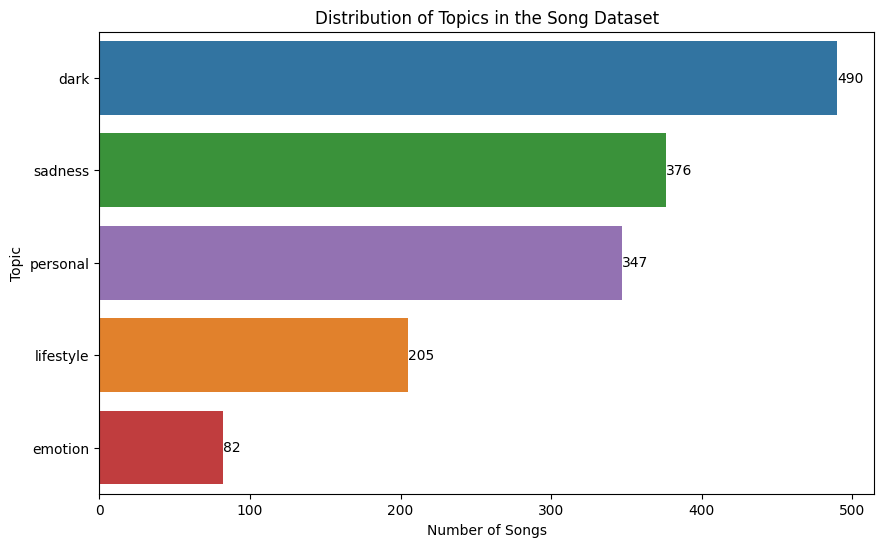

Topic counts:
topic
dark         490
sadness      376
personal     347
lifestyle    205
emotion       82
Name: count, dtype: int64


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('dataset.tsv', sep='\t')

# Plot the distribution of topics
plt.figure(figsize=(10, 6))
indexes=df['topic'].value_counts().index
ax=sns.countplot(y=df['topic'], order=indexes, hue=df.topic,legend=False)
# print(len(df['topic'].value_counts().index))
for i in range(len(indexes)):
    ax.bar_label(ax.containers[i])


plt.title('Distribution of Topics in the Song Dataset')
plt.xlabel('Number of Songs')
plt.ylabel('Topic')
plt.savefig('topic_distribution.png')
plt.show()

# Display the exact counts
print("Topic counts:")
print(df['topic'].value_counts())

The plot and counts show that the dataset is imbalanced. The `dark` topic has significantly more songs (490) than the `emotion` topic (82). Using accuracy as the sole metric for an imbalanced dataset can be misleading. A model could achieve high accuracy by simply predicting the majority class most of the time, while performing poorly on minority classes.